<h1>НИРС ОАД 2025</h1>

<h3>Подготовил студент группы ИУ5-52Б Афонин И.И.</h3>

<h3>Проблема:<br></h3>
<p>В наше время YouTube стал не только платформой для развлечения, но и СМИ. Сайт может манипулировать мнениями и трендами людей посредством трендов. Это исследование направлено на то, чтобы изучить влияние различных факторов на попадание в тренды: время суток опубликования, дата, тэги и т.д. Для исследования используем датасет данных о видео на YouTube в трендах РФ за 2020-2024 годы.</p>

<p>Гипотезы:<br>
1) Количество просмотров коррелирует с количеством лайков<br>
2) Большинство трендовых видео выходит в определённый промежуток времени<br>
3) Есть тэг, который поднимает трендовость видео<br>
4) Во время пандемии видео набирали больше просмотров, чем в другие периоды<br>
5) В определенные периоды в течение года резко меняется категорийный состав трендов</p>

<p>Для начала очистим наши данные и приведём к правильным типам:</p>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

df = pd.read_csv("RU_youtube_trending_data.csv")

df.head(5)

/home/tal3nt3d/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


,video_id,title,publishedAt,channelId,channelTitle,categoryId,trending_date,tags,view_count,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,description
0,e_Z6upbeYuc,Побег Из КАРТОННОЙ ТЮРЬМЫ Челлендж **2 часть**,2020-08-12T09:00:16Z,UC2tsySbe9TNrI-xh2lximHA,A4,24,2020-08-12T00:00:00Z,Побег Из КАРТОННОЙ ТЮРЬМЫ Челлендж **2 часть**...,5173063,1052986,29927,63557,https://i.ytimg.com/vi/e_Z6upbeYuc/default.jpg,False,False,Новые кроссовки Reebok Classic Leather Legacy ...
1,X5j69JMlbwM,DAVA & Филипп Киркоров – РОЛЕКС (Премьера клип...,2020-08-12T09:00:10Z,UCbh7BxJWCMnWLwJ-traa6Wg,DAVA,22,2020-08-12T00:00:00Z,РОЛЕКС|DAVA|Киркоров|2020|музыка в машину|музы...,636749,58770,28133,5051,https://i.ytimg.com/vi/X5j69JMlbwM/default.jpg,False,False,#Dava #ФилиппКиркоров #Ролекс #Music С огромны...
2,FzJjlIzZlVc,Как Я ЧУТЬ НЕ УМЕР 2 (анимация),2020-08-12T10:00:02Z,UCLNrn6a4Co8D6H7jRZtNPcA,X2DED,1,2020-08-12T00:00:00Z,как я чуть не умер|чуть не умер|история из жиз...,359904,45025,438,2793,https://i.ytimg.com/vi/FzJjlIzZlVc/default.jpg,False,False,Это история анимация о том как я чуть не умер ...
3,oD3FOzQDuy0,ВЫРВАЛАСЬ и УЛЕТЕЛА!!! / ТУРИЗМ 2020,2020-08-12T09:00:50Z,UCC83eap-hc6uFQHRJ2F2LNg,TheKateClapp,22,2020-08-12T00:00:00Z,катя|клэп|катюша|kate|clapp|детское|школа|смеш...,355978,64073,585,2771,https://i.ytimg.com/vi/oD3FOzQDuy0/default.jpg,False,False,"Вырвалась из КАРАНТИНА! Лучшее, что случилось ..."
4,26gteilUAuQ,Полный контакт / Соловьёв LIVE / 12 августа 20...,2020-08-12T08:43:30Z,UCQ4YOFsXjG9eXWZ6uLj2t2A,Соловьёв LIVE,25,2020-08-12T00:00:00Z,Соловьев|Владимир Соловьев|Соловьев live|solov...,428221,19329,5126,1034,https://i.ytimg.com/vi/26gteilUAuQ/default.jpg,False,False,🌞 Доброе утро!📻 Устанавливаем «Полный контакт»...


In [2]:
df.isnull().sum()
if 'description' in df.columns:
    df['description'] = df['description'].fillna('')

In [3]:
df.duplicated().sum()
df = df.drop_duplicates()

In [4]:
date_columns = ['publishedAt', 'trending_date']
for col in date_columns:
    if col in df.columns:
        if col == 'publishedAt':
            df[col] = pd.to_datetime(df[col], errors='coerce')
        elif col == 'trending_date':
            df[col] = pd.to_datetime(df[col], errors='coerce')


numeric_columns = ['view_count', 'likes', 'dislikes', 'comment_count', 'categoryId']
for col in numeric_columns:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

bool_columns = ['comments_disabled', 'ratings_disabled']
for col in bool_columns:
    if col in df.columns:
        df[col] = df[col].astype(bool)
df.dtypes

video_id                          object
title                             object
publishedAt          datetime64[ns, UTC]
channelId                         object
channelTitle                      object
categoryId                         int64
trending_date        datetime64[ns, UTC]
tags                              object
view_count                         int64
likes                              int64
dislikes                           int64
comment_count                      int64
thumbnail_link                    object
comments_disabled                   bool
ratings_disabled                    bool
description                       object
dtype: object

In [5]:
if 'tags' in df.columns:
    df['tags_clean'] = df['tags'].str.replace('|', ',', regex=False)
    df['tags_clean'] = df['tags_clean'].str.replace('"', '')
    df['tags_clean'] = df['tags_clean'].str.strip()
if 'publishedAt' in df.columns:
    df['published_year'] = df['publishedAt'].dt.year
    df['published_month'] = df['publishedAt'].dt.month
    df['published_day'] = df['publishedAt'].dt.day
    df['published_dayofweek'] = df['publishedAt'].dt.dayofweek
    df['published_hour'] = df['publishedAt'].dt.hour
if all(col in df.columns for col in ['likes', 'dislikes', 'view_count', 'comment_count']):
    df['like_ratio'] = df['likes'] / (df['likes'] + df['dislikes']).replace(0, np.nan)
    df['engagement_rate'] = ((df['likes'] + df['comment_count']) / df['view_count'] * 1000).replace([np.inf, -np.inf], np.nan)
    df['comment_density'] = (df['comment_count'] / df['view_count'] * 1000).replace([np.inf, -np.inf], np.nan)

Коэффициент корреляции Пирсона: 0.8515


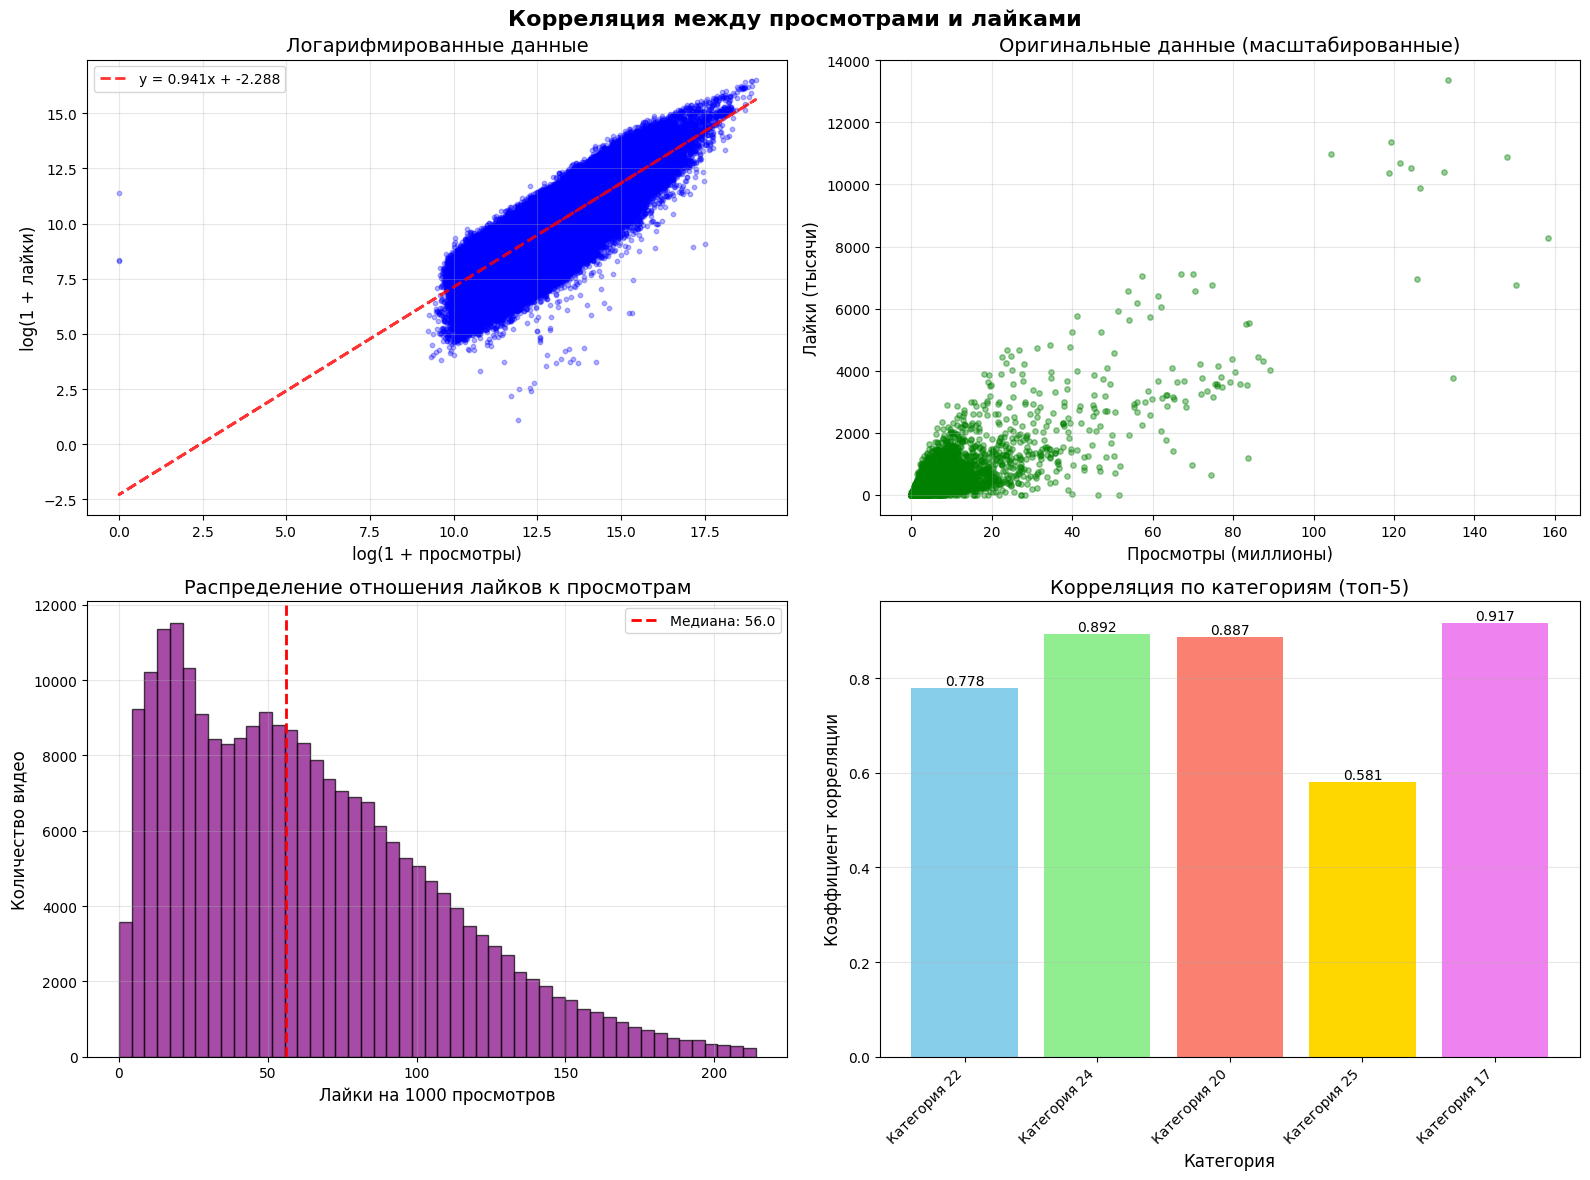

In [6]:
df_with_likes = df[df['likes'] > 0].copy()

pearson_corr = df_with_likes['view_count'].corr(df_with_likes['likes'])
spearman_corr = df_with_likes['view_count'].corr(df_with_likes['likes'], method='spearman')

print(f"Коэффициент корреляции Пирсона: {pearson_corr:.4f}")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Корреляция между просмотрами и лайками', fontsize=16, fontweight='bold')

ax1 = axes[0, 0]
scatter1 = ax1.scatter(np.log1p(df_with_likes['view_count']), 
                      np.log1p(df_with_likes['likes']), 
                      alpha=0.3, s=10, c='blue')
ax1.set_xlabel('log(1 + просмотры)', fontsize=12)
ax1.set_ylabel('log(1 + лайки)', fontsize=12)
ax1.set_title('Логарифмированные данные', fontsize=14)
ax1.grid(True, alpha=0.3)

z = np.polyfit(np.log1p(df_with_likes['view_count']), np.log1p(df_with_likes['likes']), 1)
p = np.poly1d(z)
ax1.plot(np.log1p(df_with_likes['view_count']), p(np.log1p(df_with_likes['view_count'])), 
        "r--", alpha=0.8, linewidth=2, 
        label=f'y = {z[0]:.3f}x + {z[1]:.3f}')
ax1.legend()

ax2 = axes[0, 1]

if len(df) > 100000:
    sample_df = df.sample(n=100000, random_state=42)
else:
    sample_df = df
        
scatter2 = ax2.scatter(sample_df['view_count'] / 1000000,
                      sample_df['likes'] / 1000,
                      alpha=0.4, s=15, c='green')
ax2.set_xlabel('Просмотры (миллионы)', fontsize=12)
ax2.set_ylabel('Лайки (тысячи)', fontsize=12)
ax2.set_title('Оригинальные данные (масштабированные)', fontsize=14)
ax2.grid(True, alpha=0.3)

ax3 = axes[1, 0]
df['likes_per_1000_views'] = (df['likes'] / df['view_count']) * 1000

likes_ratio_clean = df['likes_per_1000_views'].replace([np.inf, -np.inf], np.nan).dropna()
threshold = likes_ratio_clean.quantile(0.99)
likes_ratio_filtered = likes_ratio_clean[likes_ratio_clean <= threshold]

ax3.hist(likes_ratio_filtered, bins=50, color='purple', alpha=0.7, edgecolor='black')
ax3.set_xlabel('Лайки на 1000 просмотров', fontsize=12)
ax3.set_ylabel('Количество видео', fontsize=12)
ax3.set_title('Распределение отношения лайков к просмотрам', fontsize=14)
ax3.grid(True, alpha=0.3)

median_ratio = likes_ratio_filtered.median()
ax3.axvline(median_ratio, color='red', linestyle='--', linewidth=2, 
           label=f'Медиана: {median_ratio:.1f}')
ax3.legend()

ax4 = axes[1, 1]
if 'categoryId' in df.columns:
    top_categories = df['categoryId'].value_counts().head(5).index
    
    category_correlations = []
    category_names = []
    
    for category in top_categories:
        cat_df = df[df['categoryId'] == category]
        if len(cat_df) > 10:
            corr = cat_df['view_count'].corr(cat_df['likes'])
            category_correlations.append(corr)
            category_names.append(f'Категория {category}')
    
    bars = ax4.bar(range(len(category_correlations)), category_correlations, 
                  color=['skyblue', 'lightgreen', 'salmon', 'gold', 'violet'])
    ax4.set_xlabel('Категория', fontsize=12)
    ax4.set_ylabel('Коэффициент корреляции', fontsize=12)
    ax4.set_title('Корреляция по категориям (топ-5)', fontsize=14)
    ax4.set_xticks(range(len(category_correlations)))
    ax4.set_xticklabels(category_names, rotation=45, ha='right')
    ax4.grid(True, alpha=0.3, axis='y')
    
    for bar, corr in zip(bars, category_correlations):
        height = bar.get_height()
        ax4.text(bar.get_x() + bar.get_width()/2., height,
                f'{corr:.3f}', ha='center', va='bottom', fontsize=10)
else:
    ax4.hist2d(np.log1p(df['view_count']), np.log1p(df['likes']), 
              bins=50, cmap='viridis')
    ax4.set_xlabel('log(1 + просмотры)', fontsize=12)
    ax4.set_ylabel('log(1 + лайки)', fontsize=12)
    ax4.set_title('Плотность распределения (логарифм)', fontsize=14)

plt.tight_layout()
plt.show()

<p>Гипотеза подтвердилась: видим, что количество лайков растёт пропорционально количеству просмотров. То есть процент активной аудитории пропорционально растёт с ростом количества аудитории. В то же время получили медианное значение в 56 лайков/1000 просмотров, что говорит о том, что примерно 6% всей аудитории проявляет какую-то активность, остальные ведут себя более пассивно. Заметен сильный спад корреляции по категориям. К категории 25 относятся политические видео (Соловьёв Live и т.п.). Вероятно, это обусловлено тем, что данный сегмент ориентирован на более взрослых людей, которых интересует не активность в интернете, а конкретные насущные темы.</p>

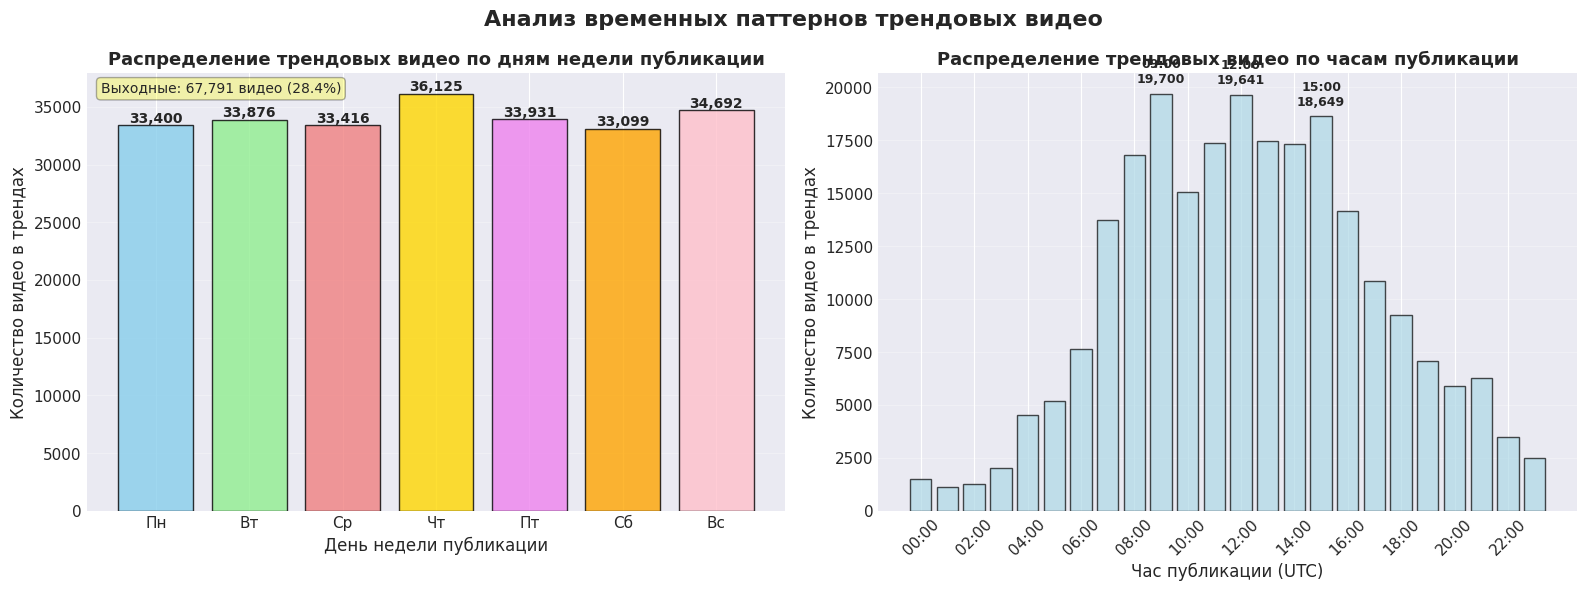

   • Коэффициент вариации: 3.1%


In [21]:
from matplotlib.ticker import FuncFormatter

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 10)
plt.rcParams['font.size'] = 11

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Анализ временных паттернов трендовых видео', fontsize=16, fontweight='bold')

ax1 = axes[0]

days_of_week = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс']

day_counts = df['published_dayofweek'].value_counts().sort_index()

bars1 = ax1.bar(range(len(day_counts)), day_counts.values, 
               color=['skyblue', 'lightgreen', 'lightcoral', 'gold', 'violet', 'orange', 'pink'],
               edgecolor='black', alpha=0.8)

ax1.set_xlabel('День недели публикации', fontsize=12)
ax1.set_ylabel('Количество видео в трендах', fontsize=12)
ax1.set_title('Распределение трендовых видео по дням недели публикации', fontsize=13, fontweight='bold')
ax1.set_xticks(range(len(days_of_week)))
ax1.set_xticklabels(days_of_week)
ax1.grid(True, alpha=0.3, axis='y')

for bar, count in zip(bars1, day_counts.values):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{count:,}', ha='center', va='bottom', fontsize=10, fontweight='bold')

weekend_indices = [5, 6]
weekend_total = day_counts.iloc[weekend_indices].sum()
weekday_total = day_counts.sum() - weekend_total
weekend_percent = weekend_total / day_counts.sum() * 100

ax1.text(0.02, 0.98, 
        f'Выходные: {weekend_total:,} видео ({weekend_percent:.1f}%)',
        transform=ax1.transAxes, fontsize=10,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.3))

ax2 = axes[1]

hour_counts = df['published_hour'].value_counts().sort_index()

bars2 = ax2.bar(range(len(hour_counts)), hour_counts.values, 
               color='lightblue', edgecolor='black', alpha=0.7)

ax2.set_xlabel('Час публикации (UTC)', fontsize=12)
ax2.set_ylabel('Количество видео в трендах', fontsize=12)
ax2.set_title('Распределение трендовых видео по часам публикации', fontsize=13, fontweight='bold')
ax2.set_xticks(range(0, 24, 2))
ax2.set_xticklabels([f'{h:02d}:00' for h in range(0, 24, 2)], rotation=45)
ax2.grid(True, alpha=0.3, axis='y')

peak_hours = hour_counts.nlargest(3)
for hour, count in peak_hours.items():
    ax2.text(hour, count * 1.02, 
            f'{hour:02d}:00\n{count:,}', 
            ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

day_std = day_counts.std()
day_mean = day_counts.mean()
cv = day_std / day_mean * 100
print(f"   • Коэффициент вариации: {cv:.1f}%")

<p>Гипотеза подтвердилась. На левом графике видно, что больше всего трендовых видео выходит в четверг, коэффициент вариации незначителен, так что можно утверждать, что день недели действительно играет важную роль в шансах на попадание в тренды. Правый график также показывает, что есть три пиковых значения, в которые наиболее высокая вероятность попасть в тренды: 9:00, 12:00 и 15:00.</p>

Всего уникальных тегов: 466,634
Всего упоминаний тегов: 4,324,317


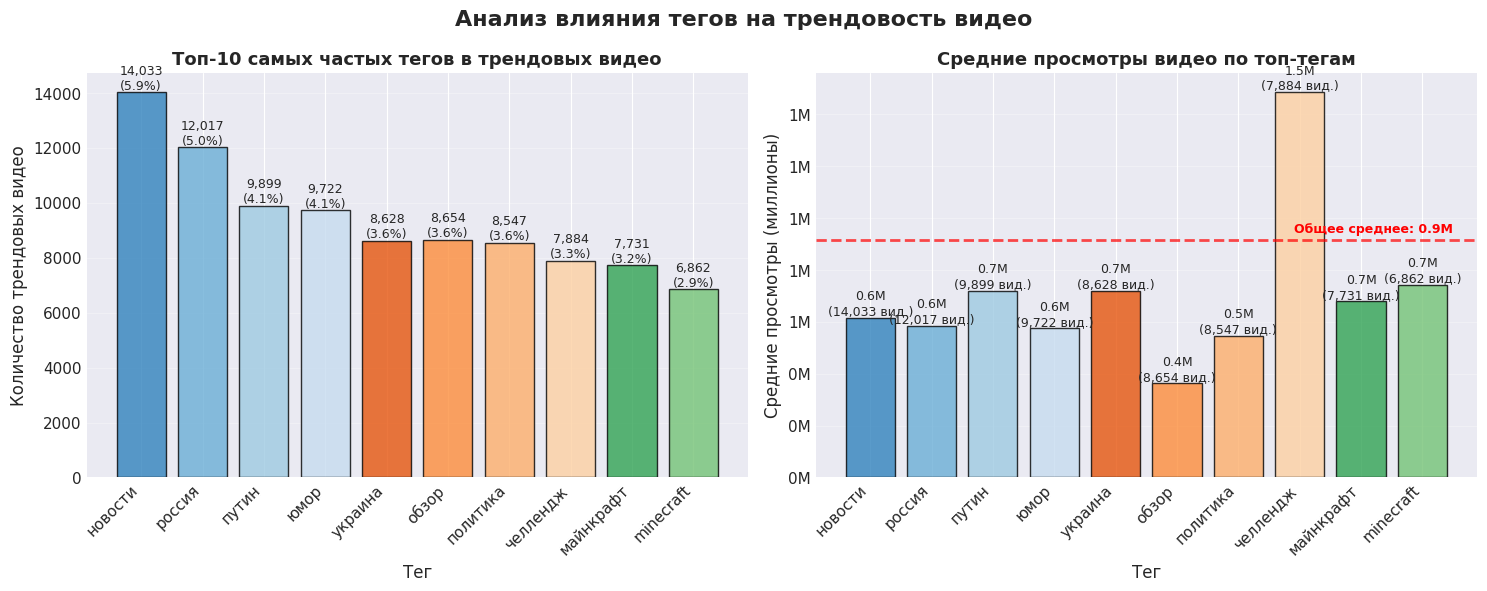

Лучший тег по просмотрам: 'челлендж'
   • Средние просмотры: 1,486,100
   • Медианные просмотры: 482,888
   • Видео с тегом: 7,884
   • На 162.2% выше общего среднего
   • Общее среднее просмотров: 915,935


In [31]:
from matplotlib.ticker import FuncFormatter

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

all_tags = []
for tag_string in df['tags_clean'].dropna():
    if tag_string and (tag_string != "[None]"): 
        tags = [tag.strip().lower() for tag in tag_string.split(',') if tag.strip()]
        all_tags.extend(tags)

print(f"Всего уникальных тегов: {len(set(all_tags)):,}")
print(f"Всего упоминаний тегов: {len(all_tags):,}")

from collections import Counter
tag_counts = Counter(all_tags)

top_10_tags = tag_counts.most_common(10)

top_tag_names = [tag for tag, _ in top_10_tags]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Анализ влияния тегов на трендовость видео', fontsize=16, fontweight='bold')

def has_tag_exact(tag_list, target_tag):
    if not tag_list or pd.isna(tag_list):
        return False
    tags_in_video = [t.strip().lower() for t in tag_list.split(',') if t.strip()]
    return target_tag.lower() in tags_in_video

avg_views_by_tag = []
video_counts_list = []

for tag, _ in top_10_tags:
    mask = df['tags_clean'].apply(lambda x: has_tag_exact(x, tag) if pd.notna(x) else False)
    videos_with_tag = df[mask]
    
    if len(videos_with_tag) > 0:
        avg_views = videos_with_tag['view_count'].mean()
        median_views = videos_with_tag['view_count'].median()
        actual_count = len(videos_with_tag)
        avg_views_by_tag.append((tag, avg_views, median_views, actual_count))
        video_counts_list.append(actual_count)
    else:
        avg_views_by_tag.append((tag, 0, 0, 0))
        video_counts_list.append(0)
        
tags = [tag[:20] + '...' if len(tag) > 20 else tag for tag, _, _, _ in avg_views_by_tag]
actual_counts = [count for _, _, _, count in avg_views_by_tag]

bars1 = ax1.bar(range(len(tags)), actual_counts, 
               color=plt.cm.tab20c(np.arange(len(tags))),
               edgecolor='black', alpha=0.8)

ax1.set_xlabel('Тег', fontsize=12)
ax1.set_ylabel('Количество трендовых видео', fontsize=12)
ax1.set_title('Топ-10 самых частых тегов в трендовых видео', fontsize=13, fontweight='bold')
ax1.set_xticks(range(len(tags)))
ax1.set_xticklabels(tags, rotation=45, ha='right')
ax1.grid(True, alpha=0.3, axis='y')

for bar, count in zip(bars1, actual_counts):
    height = bar.get_height()
    percentage = count / len(df) * 100
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{count:,}\n({percentage:.1f}%)', 
            ha='center', va='bottom', fontsize=9)

tags_for_plot = [tag[:20] + '...' if len(tag) > 20 else tag for tag, _, _, _ in avg_views_by_tag]
avg_views_values = [avg_views for _, avg_views, _, _ in avg_views_by_tag]
video_counts = [count for _, _, _, count in avg_views_by_tag]

bars2 = ax2.bar(range(len(tags_for_plot)), avg_views_values,
               color=plt.cm.tab20c(np.arange(len(tags_for_plot))),
               edgecolor='black', alpha=0.8)

ax2.set_xlabel('Тег', fontsize=12)
ax2.set_ylabel('Среднее количество просмотров', fontsize=12)
ax2.set_title('Средние просмотры видео по топ-тегам', fontsize=13, fontweight='bold')
ax2.set_xticks(range(len(tags_for_plot)))
ax2.set_xticklabels(tags_for_plot, rotation=45, ha='right')
ax2.grid(True, alpha=0.3, axis='y')

def millions_formatter(x, pos):
    return f'{x/1e6:.0f}M'

ax2.yaxis.set_major_formatter(FuncFormatter(millions_formatter))
ax2.set_ylabel('Средние просмотры (миллионы)', fontsize=12)

for i, (bar, avg_views, video_count) in enumerate(zip(bars2, avg_views_values, video_counts)):
    height = avg_views
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'{avg_views/1e6:.1f}M\n({video_count:,} вид.)', 
            ha='center', va='bottom', fontsize=9)

overall_avg_views = df['view_count'].mean()
ax2.axhline(y=overall_avg_views, color='red', linestyle='--', alpha=0.7, linewidth=2)
ax2.text(len(tags_for_plot) - 0.5, overall_avg_views * 1.02,
        f'Общее среднее: {overall_avg_views/1e6:.1f}M',
        ha='right', va='bottom', color='red', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

best_tag_info = max(avg_views_by_tag, key=lambda x: x[1])
worst_tag_info = min(avg_views_by_tag, key=lambda x: x[1])

print(f"Лучший тег по просмотрам: '{best_tag_info[0]}'")
print(f"   • Средние просмотры: {best_tag_info[1]:,.0f}")
print(f"   • Медианные просмотры: {best_tag_info[2]:,.0f}")
print(f"   • Видео с тегом: {best_tag_info[3]:,}")
print(f"   • На {best_tag_info[1]/overall_avg_views*100:.1f}% выше общего среднего")
print(f"   • Общее среднее просмотров: {overall_avg_views:,.0f}")

<p>Гипотеза верна. Самым часто используемым тэгом за исследуемый период стал тэг "новости", но при этом в среднем видео с этим тэгом набирали 600 тысяч просмотров. В то же время тэг "челлендж" в среднем приносит 1,5 миллиона просмотров, что делает его самым просматривыемым тэгом. Таким образом, можно утверждать, что этот тэг действительно влияет на попадание в тренды.</p>

Период анализа: 2020-08-10 - 2024-04-15


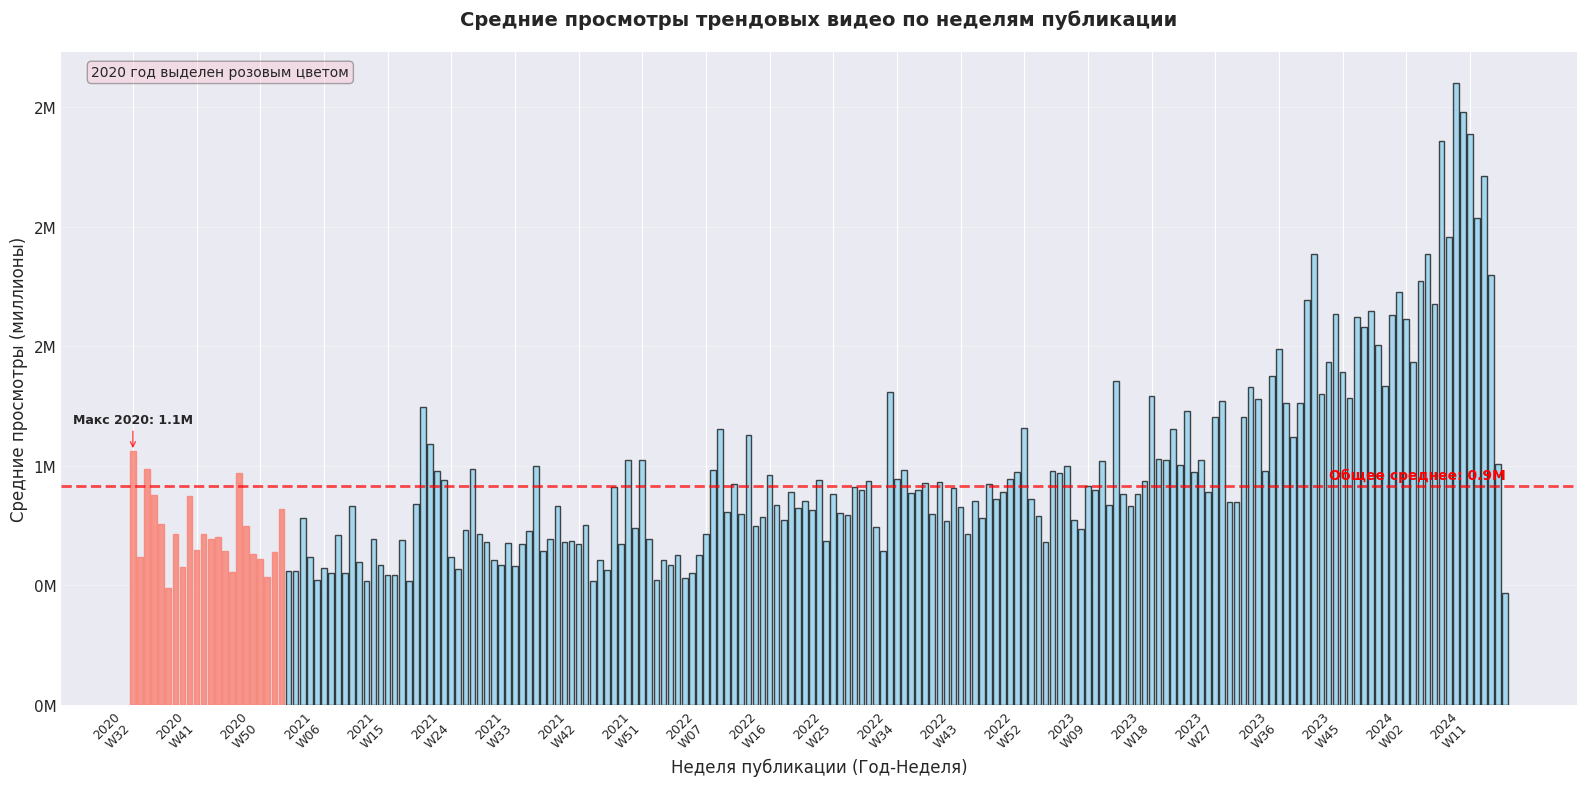

2020.0: 702,249 просмотров (27,903.0 видео)
2021.0: 710,596 просмотров (73,397.0 видео)
2022.0: 842,851 просмотров (67,529.0 видео)
2023.0: 1,147,623 просмотров (57,160.0 видео)
2024.0: 1,929,933 просмотров (12,550.0 видео)

Сравнение 2020 года с другими годами:
• 2020 год: 702,249 просмотров
• Среднее других лет: 1,157,751 просмотров
• Разница: -39.3%


In [34]:
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.size'] = 11

if 'publishedAt' in df.columns:
    df['published_week'] = df['publishedAt'].dt.isocalendar().week
    df['published_year'] = df['publishedAt'].dt.year
    df['year_week'] = df['published_year'].astype(str) + '-W' + df['published_week'].astype(str).str.zfill(2)
    
    weekly_stats = df.groupby(['published_year', 'published_week']).agg({
        'view_count': ['median', 'mean', 'count'],
        'video_id': 'count'
    }).round(0)
    
    weekly_stats.columns = ['median_views', 'mean_views', 'view_count_sum', 'video_count']
    weekly_stats = weekly_stats.reset_index()
    
    weekly_stats['date_str'] = weekly_stats['published_year'].astype(str) + '-W' + weekly_stats['published_week'].astype(str).str.zfill(2)
    weekly_stats['week_start'] = pd.to_datetime(weekly_stats['date_str'] + '-1', format='%Y-W%W-%w')
    
    weekly_stats = weekly_stats.sort_values('week_start')
    
    weekly_stats['x_label'] = weekly_stats['published_year'].astype(str) + '\nW' + weekly_stats['published_week'].astype(str).str.zfill(2)
    
    print(f"Период анализа: {weekly_stats['week_start'].min().date()} - {weekly_stats['week_start'].max().date()}")
    
    fig, ax = plt.subplots(figsize=(16, 8))
    
    bars = ax.bar(range(len(weekly_stats)), weekly_stats['mean_views'], 
                 color='skyblue', edgecolor='black', alpha=0.7, width=0.8)
    
    for i, (idx, row) in enumerate(weekly_stats.iterrows()):
        if row['published_year'] == 2020:
            bars[i].set_color('salmon')
            bars[i].set_alpha(0.8)
    
    ax.set_xlabel('Неделя публикации (Год-Неделя)', fontsize=12)
    ax.set_ylabel('Среднее количество просмотров', fontsize=12)
    ax.set_title('Средние просмотры трендовых видео по неделям публикации', 
                fontsize=14, fontweight='bold', pad=20)
    
    step = max(1, len(weekly_stats) // 20)
    xticks_positions = range(0, len(weekly_stats), step)
    xticks_labels = [weekly_stats.iloc[i]['x_label'] for i in xticks_positions]
    
    ax.set_xticks(xticks_positions)
    ax.set_xticklabels(xticks_labels, rotation=45, ha='right', fontsize=9)
    
    def millions_formatter(x, pos):
        return f'{x/1e6:.0f}M'
    
    ax.yaxis.set_major_formatter(FuncFormatter(millions_formatter))
    ax.set_ylabel('Средние просмотры (миллионы)', fontsize=12)
    
    overall_mean = df['view_count'].mean()
    ax.axhline(y=overall_mean, color='red', linestyle='--', alpha=0.7, linewidth=2)
    ax.text(len(weekly_stats) - 1, overall_mean * 1.02,
            f'Общее среднее: {overall_mean/1e6:.1f}M',
            ha='right', va='bottom', color='red', fontsize=10, fontweight='bold')
    
    ax.text(0.02, 0.98, '2020 год выделен розовым цветом',
            transform=ax.transAxes, fontsize=10,
            verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='lightpink', alpha=0.3))
    
    ax.grid(True, alpha=0.3, axis='y')
    
    if 2020 in weekly_stats['published_year'].values:
        weeks_2020 = weekly_stats[weekly_stats['published_year'] == 2020]
        if len(weeks_2020) > 0:
            max_2020 = weeks_2020['mean_views'].max()
            avg_2020 = weeks_2020['mean_views'].mean()
            
            max_idx = weeks_2020['mean_views'].idxmax()
            max_pos = weekly_stats.index.get_loc(max_idx)
            
            ax.annotate(f'Макс 2020: {max_2020/1e6:.1f}M', 
                       xy=(max_pos, max_2020),
                       xytext=(max_pos, max_2020 * 1.1),
                       ha='center', va='bottom',
                       fontsize=9, fontweight='bold',
                       arrowprops=dict(arrowstyle='->', color='red', alpha=0.7))
    
    plt.tight_layout()
    plt.show()
    
    yearly_stats = df.groupby('published_year').agg({
        'view_count': ['median', 'mean', 'count'],
        'video_id': 'count'
    }).round(0)
    
    yearly_stats.columns = ['median_views', 'mean_views', 'view_count_sum', 'video_count']
    yearly_stats = yearly_stats.reset_index()
    
    for _, row in yearly_stats.iterrows():
        print(f"{row['published_year']}: {row['mean_views']:,.0f} просмотров ({row['video_count']:,} видео)")
    
    if 2020 in yearly_stats['published_year'].values:
        stats_2020 = yearly_stats[yearly_stats['published_year'] == 2020].iloc[0]
        other_years = yearly_stats[yearly_stats['published_year'] != 2020]
        
        avg_other_years = other_years['mean_views'].mean()
        diff_percent = (stats_2020['mean_views'] - avg_other_years) / avg_other_years * 100
        
        print(f"\nСравнение 2020 года с другими годами:")
        print(f"• 2020 год: {stats_2020['mean_views']:,.0f} просмотров")
        print(f"• Среднее других лет: {avg_other_years:,.0f} просмотров")
        print(f"• Разница: {diff_percent:+.1f}%")

<p>Гипотеза опровергнута. К сожалению, имеющиеся данные относятся только ко второй волне заболеваемости Covid-19. Тем не менее, несмотря на замедление платформы YouTube, пандемию и прочие факторы, просмотры роликов в 2020 году были меньше, чем в каждый из последующих годов. В целом наблюдается стабильный рост количества просмотров.</p>

=== ПРОВЕРКА ГИПОТЕЗЫ ===
В определенные дни резко меняется категорийный состав трендов


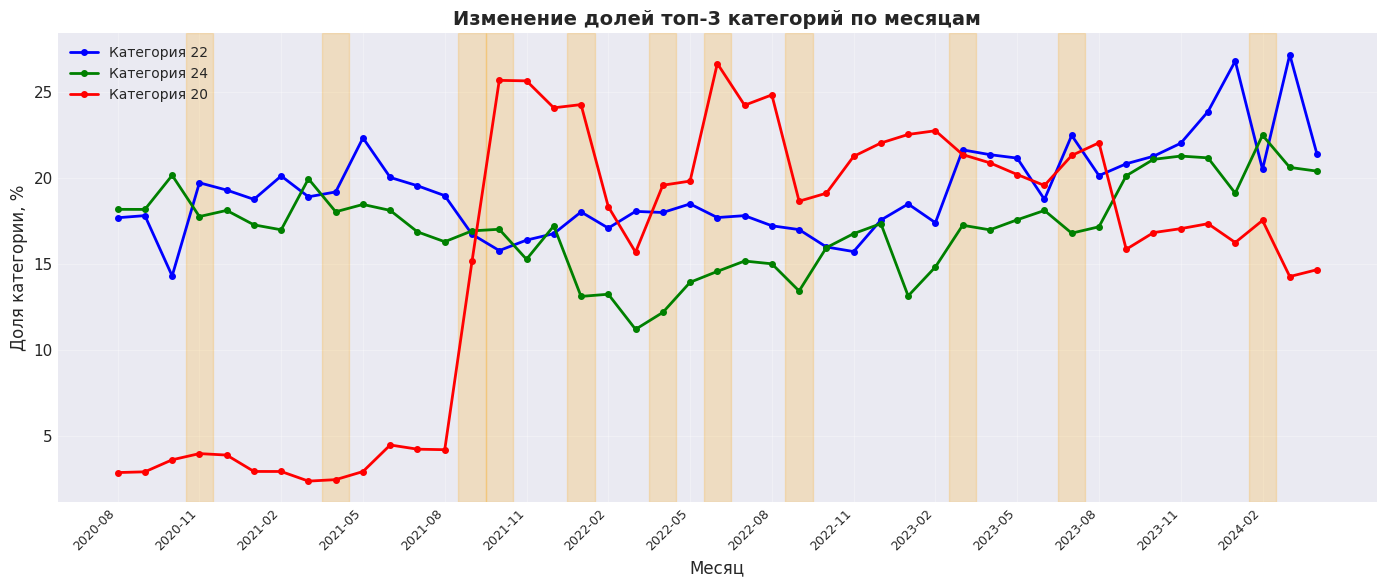

In [43]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.size'] = 11

top_n_categories = 10
top_categories = df['categoryId'].value_counts().head(top_n_categories).index.tolist()

df['published_month'] = df['publishedAt'].dt.month
df['published_year'] = df['publishedAt'].dt.year
df['year_month'] = df['published_year'].astype(str) + '-' + df['published_month'].astype(str).str.zfill(2)
df['month_date'] = pd.to_datetime(df['year_month'] + '-01', format='%Y-%m-%d')

df_filtered = df[df['categoryId'].isin(top_categories)].copy()
category_order = df_filtered['categoryId'].value_counts().index.tolist()

monthly_stats = df_filtered.groupby(['year_month', 'categoryId']).size().unstack(fill_value=0)
monthly_percent = monthly_stats.div(monthly_stats.sum(axis=1), axis=0) * 100

month_columns = sorted(monthly_percent.index, key=lambda x: pd.to_datetime(x + '-01', format='%Y-%m-%d'))
monthly_percent = monthly_percent.reindex(month_columns)
monthly_percent = monthly_percent.reindex(columns=category_order)

top_3_categories = category_order[:3]
colors = ['blue', 'green', 'red']

fig, ax = plt.subplots(figsize=(14, 6))
    
for i, cat in enumerate(top_3_categories):
    if cat in monthly_percent.columns:
        ax.plot(range(len(monthly_percent)), monthly_percent[cat], 
                label=f'Категория {cat}', color=colors[i], linewidth=2, marker='o', markersize=4)

ax.set_xlabel('Месяц', fontsize=12)
ax.set_ylabel('Доля категории, %', fontsize=12)
ax.set_title('Изменение долей топ-3 категорий по месяцам', fontsize=14, fontweight='bold')

step = max(1, len(month_columns) // 12)
visible_xticks = range(0, len(month_columns), step)
visible_xlabels = [month_columns[i] for i in visible_xticks]

ax.set_xticks(visible_xticks)
ax.set_xticklabels(visible_xlabels, rotation=45, ha='right', fontsize=9)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

monthly_changes = monthly_percent.diff().abs().sum(axis=1)
threshold = monthly_changes.quantile(0.75)

for idx in monthly_changes[monthly_changes > threshold].index:
    pos = month_columns.index(idx)
    ax.axvspan(pos-0.5, pos+0.5, alpha=0.2, color='orange')

plt.tight_layout()
plt.show()

<p>Гипотеза верна частично. Действительно существуют периоды смены популярностей конкретных категорий видео, но они не имеют периодичность и сезонность. Вероятно, они связаны с какими-то с внешними факторами (общемировые ситуации, мемы, тренды). То есть не получилось установить зависимость категорий трендовых видео от времени года.</p>

<h3>Подведём итоги:<br></h3>
<p>По результатам анализа мы подтвердили следующие гипотезы: зависимость количества лайков от количества просмотров действительно существует; действительно есть дни и периоды в сутках, в которые опубликованное видео с большей вероятностью попадёт в тренды; тэг напрямую влияет на количество просмотров, используя определённые тэги можно значительно увеличить просмотры.<br>
Следующие гипотезы не смогли быть подтверждены полностью: во время пандемии просмотры не были выше, чем остальные периоды, более того, количество просмотров постоянно растёт, несмотря на внешние факторы; не была определена зависимость трендовых категорий от времени года, но было установлено, что в некоторые периоды категории действительно набирают/теряют популярность.<br>
Таким образом, действительно можно оказывать влияние на вероятность попадания видео в тренды с помощью вышеуказанных примеров.</p>